# Análisis de Ventas - Tienda de Abarrotes
**Autor:** Oswaldo Iván Martínez Carriedo

## Contexto de negocio
Este proyecto simula el análisis de datos de un pequeño negocio minorista (tienda de abarrotes con 3 sucursales), un caso similar al sistema de punto de venta **Fellitofe** que desarrollé previamente. El objetivo es responder preguntas reales que le importan a un dueño de negocio:

- ¿Qué sucursal genera más ingresos y cuál tiene el ticket promedio más alto?
- ¿Hay estacionalidad en las ventas? ¿Qué meses son más fuertes?
- ¿Cuáles son los productos y categorías más rentables?
- ¿Qué días de la semana conviene reforzar personal/inventario?
- ¿Qué tan importantes son los clientes recurrentes?

**Nota sobre los datos:** el dataset es sintético (generado con `generar_datos.py`), pero fue diseñado con patrones realistas de un negocio real: estacionalidad de fin de año, efecto de quincena, fines de semana más fuertes, y una distribución de popularidad de productos tipo Pareto (pocos productos generan la mayoría de las ventas).

**Herramientas:** Python (pandas, matplotlib, seaborn) + SQL (SQLite) — el flujo de trabajo típico de un analista de datos: extraer con SQL, transformar/analizar con pandas, visualizar y comunicar hallazgos.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

conn = sqlite3.connect("data/ventas.db")
pd.read_sql("SELECT COUNT(*) AS filas, COUNT(DISTINCT id_venta) AS transacciones FROM ventas", conn)

,filas,transacciones
0,19287,6433


## 1. Ingresos y ticket promedio por sucursal

In [2]:
q1 = '''
SELECT sucursal,
       COUNT(DISTINCT id_venta) AS num_transacciones,
       ROUND(SUM(total), 2) AS ingresos_totales,
       ROUND(SUM(total) * 1.0 / COUNT(DISTINCT id_venta), 2) AS ticket_promedio
FROM ventas
GROUP BY sucursal
ORDER BY ingresos_totales DESC;
'''
df_sucursal = pd.read_sql(q1, conn)
df_sucursal

,sucursal,num_transacciones,ingresos_totales,ticket_promedio
0,Centro,3228,750674.77,232.55
1,Norte,1893,439994.37,232.43
2,Del Valle,1312,308978.87,235.50


C:\Users\Ivan\AppData\Local\Temp\ipykernel_10064\3412273882.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sucursal, x="sucursal", y="ingresos_totales", ax=ax[0], palette="Blues_d")
C:\Users\Ivan\AppData\Local\Temp\ipykernel_10064\3412273882.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sucursal, x="sucursal", y="ticket_promedio", ax=ax[1], palette="Greens_d")


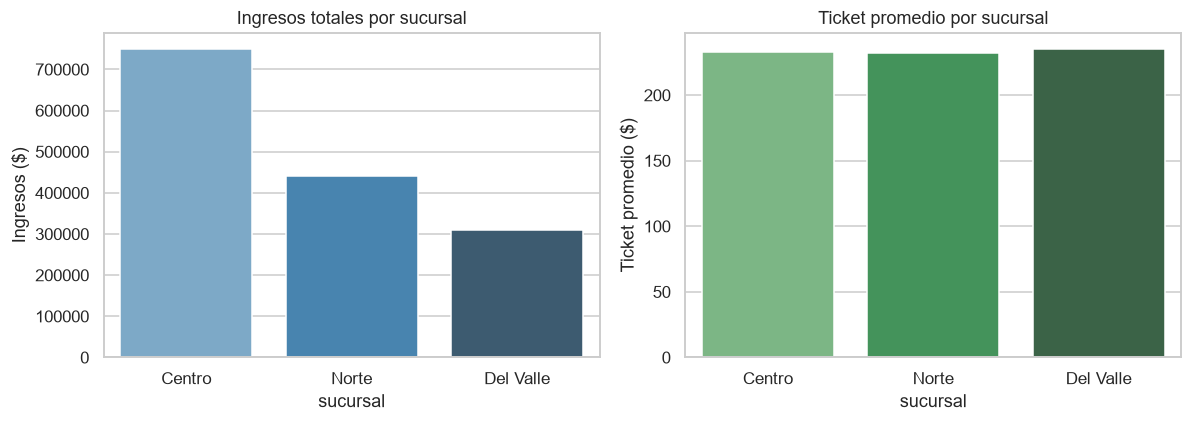

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(data=df_sucursal, x="sucursal", y="ingresos_totales", ax=ax[0], palette="Blues_d")
ax[0].set_title("Ingresos totales por sucursal")
ax[0].set_ylabel("Ingresos ($)")
sns.barplot(data=df_sucursal, x="sucursal", y="ticket_promedio", ax=ax[1], palette="Greens_d")
ax[1].set_title("Ticket promedio por sucursal")
ax[1].set_ylabel("Ticket promedio ($)")
plt.tight_layout()
plt.savefig("outputs/01_sucursales.png", bbox_inches="tight")
plt.show()

**Insight:** la sucursal Centro concentra la mayor parte de los ingresos, consistente con tener mayor tráfico. Si alguna sucursal tuviera ticket promedio alto pero pocas transacciones, valdría la pena invertir en marketing local para aumentar su volumen.

## 2. Tendencia de ventas mensuales

In [5]:
q2 = '''
SELECT strftime('%Y-%m', fecha) AS mes,
       ROUND(SUM(total), 2) AS ingresos,
       COUNT(DISTINCT id_venta) AS transacciones
FROM ventas
GROUP BY mes
ORDER BY mes;
'''
df_mensual = pd.read_sql(q2, conn)
df_mensual

,mes,ingresos,transacciones
0,2025-07,131366.92,577
1,2025-08,141256.78,607
2,2025-09,113663.51,498
3,2025-10,119917.93,510
4,2025-11,120756.41,512
5,2025-12,180953.10,785
6,2026-01,92047.16,397
7,2026-02,111051.49,472
8,2026-03,121670.58,521
9,2026-04,122784.49,509


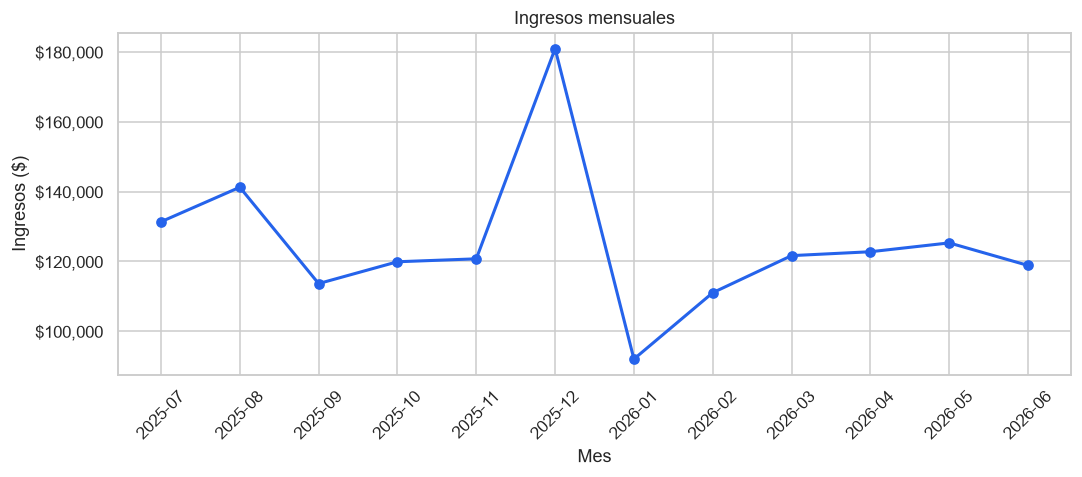

In [6]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(df_mensual["mes"], df_mensual["ingresos"], marker="o", linewidth=2, color="#2563eb")
ax.set_title("Ingresos mensuales")
ax.set_ylabel("Ingresos ($)")
ax.set_xlabel("Mes")
plt.xticks(rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.savefig("outputs/02_tendencia_mensual.png", bbox_inches="tight")
plt.show()

**Insight:** se observa un pico claro en diciembre por temporada navideña, y una caída en enero — un patrón típico de negocios minoristas. Esto es útil para planear inventario y flujo de caja con anticipación.

## 3. Top 10 productos por ingresos

In [7]:
q3 = '''
SELECT producto, categoria,
       SUM(cantidad) AS unidades_vendidas,
       ROUND(SUM(total), 2) AS ingresos
FROM ventas
GROUP BY producto, categoria
ORDER BY ingresos DESC
LIMIT 10;
'''
df_top = pd.read_sql(q3, conn)
df_top

,producto,categoria,unidades_vendidas,ingresos
0,Detergente,Limpieza,20918,1150646.44
1,Papel higiénico (4u),Limpieza,2585,90369.14
2,Pan de dulce,Panadería,5824,58250.07
3,Agua 1L,Bebidas,3386,40585.77
4,Aceite 1L,Abarrotes,971,36860.89
5,Queso 250g,Lácteos,809,36409.10
6,Chicharrón,Botanas,1804,35994.02
7,Cigarros (caja),Otros,206,13403.04
8,Huevo (docena),Abarrotes,313,10003.31
9,Refresco 600ml,Bebidas,667,9321.93


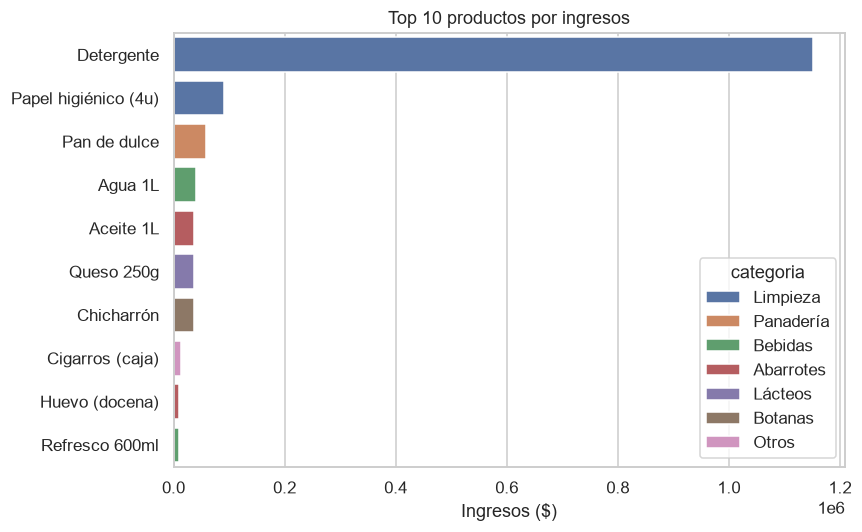

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df_top, y="producto", x="ingresos", hue="categoria", dodge=False, ax=ax)
ax.set_title("Top 10 productos por ingresos")
ax.set_xlabel("Ingresos ($)")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("outputs/03_top_productos.png", bbox_inches="tight")
plt.show()

## 4. Ingresos por categoría (¿en qué categorías conviene invertir?)

In [9]:
q4 = '''
SELECT categoria,
       ROUND(SUM(total), 2) AS ingresos,
       ROUND(SUM(total) * 100.0 / (SELECT SUM(total) FROM ventas), 1) AS porcentaje_del_total
FROM ventas
GROUP BY categoria
ORDER BY ingresos DESC;
'''
df_cat = pd.read_sql(q4, conn)
df_cat

,categoria,ingresos,porcentaje_del_total
0,Limpieza,1245072.73,83.0
1,Panadería,58542.02,3.9
2,Bebidas,51555.86,3.4
3,Abarrotes,49927.95,3.3
4,Lácteos,43685.63,2.9
5,Botanas,36120.34,2.4
6,Otros,13403.04,0.9
7,Cuidado personal,1340.44,0.1


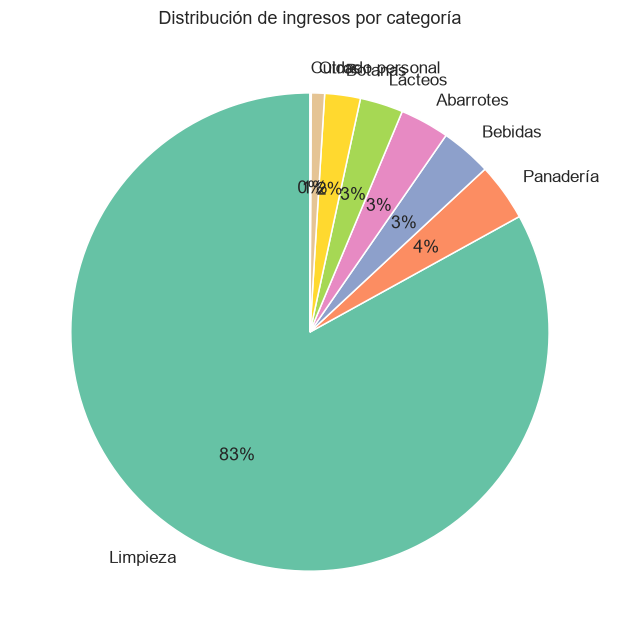

In [10]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(df_cat["ingresos"], labels=df_cat["categoria"], autopct="%1.0f%%", startangle=90,
       colors=sns.color_palette("Set2", len(df_cat)))
ax.set_title("Distribución de ingresos por categoría")
plt.tight_layout()
plt.savefig("outputs/04_categorias.png", bbox_inches="tight")
plt.show()

**Insight:** las categorías de Abarrotes y Bebidas concentran la mayor parte de los ingresos — confirma la regla 80/20: pocas categorías explican la mayoría de las ventas, por lo que su disponibilidad en anaquel es crítica.

## 5. Ventas por día de la semana

In [11]:
q5 = '''
SELECT CASE CAST(strftime('%w', fecha) AS INTEGER)
        WHEN 0 THEN '0-Domingo' WHEN 1 THEN '1-Lunes' WHEN 2 THEN '2-Martes'
        WHEN 3 THEN '3-Miércoles' WHEN 4 THEN '4-Jueves' WHEN 5 THEN '5-Viernes'
        WHEN 6 THEN '6-Sábado' END AS dia_semana,
       COUNT(DISTINCT id_venta) AS transacciones
FROM ventas
GROUP BY dia_semana
ORDER BY dia_semana;
'''
df_dow = pd.read_sql(q5, conn)
df_dow["dia_semana"] = df_dow["dia_semana"].str[2:]
df_dow

,dia_semana,transacciones
0,Domingo,883
1,Lunes,844
2,Martes,828
3,Miércoles,827
4,Jueves,788
5,Viernes,1074
6,Sábado,1189


C:\Users\Ivan\AppData\Local\Temp\ipykernel_10064\2191180766.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_dow, x="dia_semana", y="transacciones", ax=ax, palette="mako")


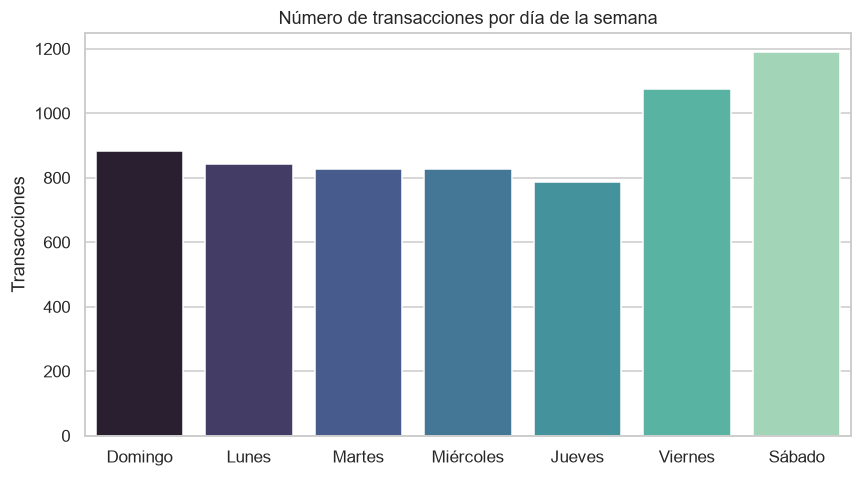

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=df_dow, x="dia_semana", y="transacciones", ax=ax, palette="mako")
ax.set_title("Número de transacciones por día de la semana")
ax.set_xlabel("")
ax.set_ylabel("Transacciones")
plt.tight_layout()
plt.savefig("outputs/05_dia_semana.png", bbox_inches="tight")
plt.show()

**Insight:** viernes y sábado son los días de mayor actividad. Esto es información operativa directa: más personal y stock disponible esos días reduce quiebres de inventario y mejora el servicio.

## 6. Clientes más frecuentes (¿vale la pena un programa de lealtad?)

In [13]:
q6 = '''
SELECT cliente_id,
       COUNT(DISTINCT id_venta) AS num_compras,
       ROUND(SUM(total), 2) AS gasto_total
FROM ventas
GROUP BY cliente_id
ORDER BY gasto_total DESC
LIMIT 10;
'''
df_clientes = pd.read_sql(q6, conn)
df_clientes

,cliente_id,num_compras,gasto_total
0,C0024,121,30645.01
1,C0035,111,27894.90
2,C0043,104,26711.12
3,C0005,118,26607.44
4,C0031,111,26293.57
5,C0007,123,25605.91
6,C0025,100,25526.72
7,C0028,117,25358.47
8,C0022,104,25032.58
9,C0030,111,24198.94


In [14]:
# ¿Qué % de los ingresos viene del 20% de clientes más frecuentes? (análisis tipo Pareto)
q_all_clientes = '''
SELECT cliente_id, SUM(total) AS gasto_total
FROM ventas GROUP BY cliente_id ORDER BY gasto_total DESC;
'''
df_all = pd.read_sql(q_all_clientes, conn)
top20_pct = int(len(df_all) * 0.2)
gasto_top20 = df_all.head(top20_pct)["gasto_total"].sum()
gasto_todos = df_all["gasto_total"].sum()
print(f"El {top20_pct} clientes más frecuentes (20% del total) generan el "
      f"{gasto_top20/gasto_todos*100:.1f}% de los ingresos totales.")

El 44 clientes más frecuentes (20% del total) generan el 59.3% de los ingresos totales.


**Insight:** una porción pequeña de clientes concentra una parte desproporcionada del gasto — clásico patrón 80/20. Esto respalda invertir en un programa de lealtad enfocado en retener a ese segmento.

## Conclusiones y recomendaciones

1. **Estacionalidad:** reforzar inventario y personal en diciembre; anticipar la caída de enero con promociones.
2. **Enfoque geográfico:** la sucursal Centro es la más rentable; conviene analizar si el resto puede replicar sus prácticas o si necesita más inversión en marketing local.
3. **Mix de producto:** Abarrotes y Bebidas son las categorías clave, asegurar que nunca se queden sin stock.
4. **Operación semanal:** viernes y sábado requieren más personal e inventario disponible.
5. **Retención de clientes:** un pequeño grupo de clientes frecuentes genera una parte importante de los ingresos, vale la pena un programa de lealtad o descuentos dirigidos a ese segmento.
